In [43]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [44]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [45]:
X_train.shape

(60000, 28, 28)

In [46]:
X_test.shape

(10000, 28, 28)

In [47]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

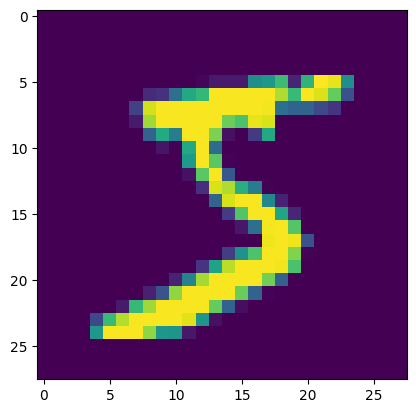

In [48]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [49]:
X_train = X_train/255
X_test = X_test/255

In [50]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(loss='sparse_categorical_crossentropy' , optimizer='Adam', metrics =['accuracy'])

In [53]:
hisory = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9190 - loss: 0.2761 - val_accuracy: 0.9582 - val_loss: 0.1468
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9639 - loss: 0.1178 - val_accuracy: 0.9684 - val_loss: 0.1054
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9754 - loss: 0.0817 - val_accuracy: 0.9676 - val_loss: 0.1076
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9800 - loss: 0.0635 - val_accuracy: 0.9710 - val_loss: 0.0985
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9844 - loss: 0.0485 - val_accuracy: 0.9734 - val_loss: 0.0978


In [54]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [55]:
y_pred = y_prob.argmax(axis=1)

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9747

/tmp/ipykernel_1095/3359624589.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


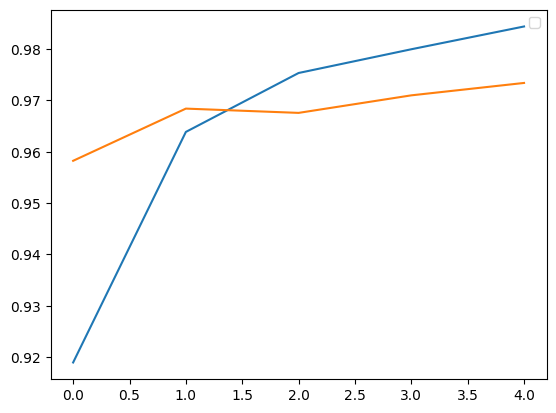

In [ ]:
plt.plot(hisory.history['accuracy'], label='accuracy')
plt.plot(hisory.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()